# Week 4 Deep Learning - CIFAR-10 Image Classification
Building and comparing ANN and CNN models on CIFAR-10 dataset to classify images into 10 categories.
## PART-1: Setup and Load Data
Loading CIFAR-10 dataset with 60000 training images and 10000 test images across 10 object categories.



In [1]:
# importing all libraries for deep learning on CIFAR-10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("All imports done successfully ")

All imports done successfully 


## Loading and Exploring the Data
Downloading CIFAR-10 dataset and visualizing sample images from each category,- 60000 training images and 10000 test images.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)
Number of classes: 10


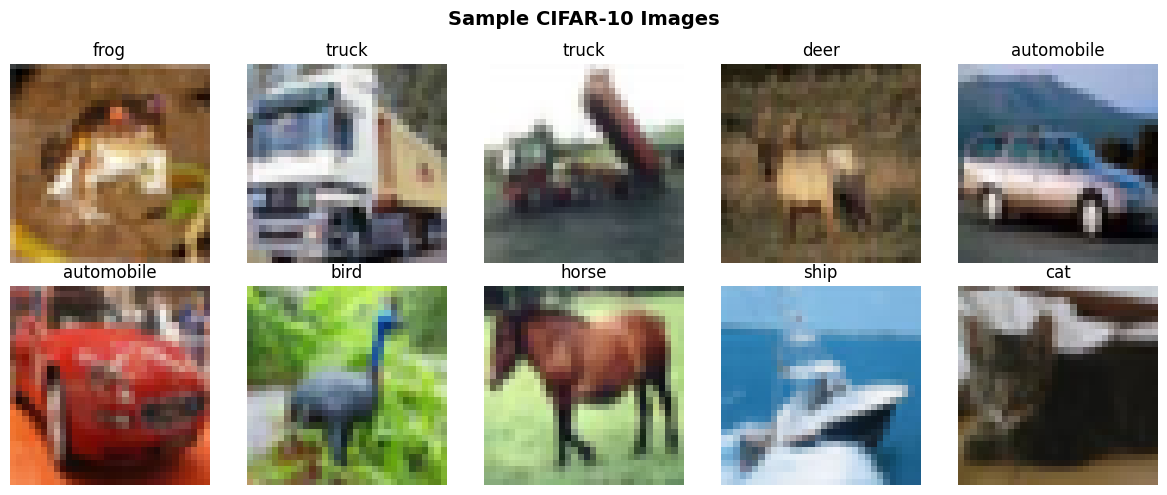


Dataset loaded successfully 


In [3]:
# loading CIFAR-10 dataset which contains 60000 images across 10 categories
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# names for 10 categories
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# checking dataset dimensions
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Number of classes:", len(class_names))

# first visualize 10 images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    axes[i//5, i%5].imshow(X_train[i])
    axes[i//5, i%5].set_title(class_names[y_train[i][0]])
    axes[i//5, i%5].axis('off')

plt.suptitle('Sample CIFAR-10 Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDataset loaded successfully ")

## Preprocessing the Data
Normalizing pixel values and converting labels to one-hot encoding for neural networks.

In [4]:
# normalize pixel values to 0-1 range
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# convert labels to one-hot encoding
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print("Training data normalized - shape:", X_train.shape)
print("Training labels encoded - shape:", y_train_encoded.shape)
print("Preprocessing done ")

Training data normalized - shape: (50000, 32, 32, 3)
Training labels encoded - shape: (50000, 10)
Preprocessing done 


## Building ANN Model

Creating and training a fully connected neural network for image classification.

In [6]:
# flatten the images for ANN
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened training data shape:", X_train_flat.shape)

# building ANN model
ann_model = Sequential([
    Dense(512, activation='relu', input_shape=(3072,)),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

# compile the model
ann_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("\nANN Model Architecture:")
ann_model.summary()

# training the ANN model
print("\nTraining ANN model...")
ann_history = ann_model.fit(X_train_flat, y_train_encoded,
                            epochs=20,
                            batch_size=128,
                            validation_split=0.2,
                            verbose=1)

print("\nANN training completed ")

Flattened training data shape: (50000, 3072)

ANN Model Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


Training ANN model...
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.2453 - loss: 2.0440 - val_accuracy: 0.3379 - val_loss: 1.8346
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.3199 - loss: 1.8663 - val_accuracy: 0.3627 - val_loss: 1.7641
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.3451 - loss: 1.8069 - val_accuracy: 0.3711 - val_loss: 1.7351
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.3608 - loss: 1.7615 - val_accuracy: 0.3942 - val_loss: 1.7015
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.3714 - loss: 1.7378 - val_accuracy: 0.4116 - val_loss: 1.6682
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.3803 - loss: 1.7149 - val_accuracy: 0.4073 - val_loss: 1.6646
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.3841 - loss: 1.7015 - val_accuracy: 0.4065 - val_loss: 1.6565
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0

## Evaluating ANN Performance

Analyzing ANN model results with accuracy metrics, loss curves, and confusion matrix.

ANN Test Accuracy: 0.4711
ANN Test Loss: 1.5152


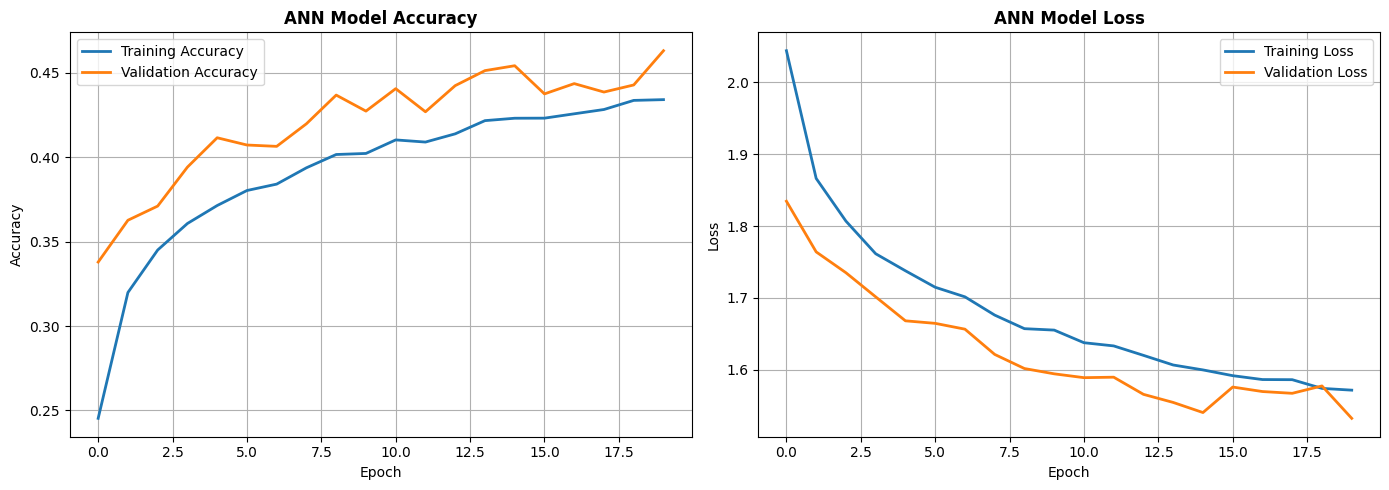

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


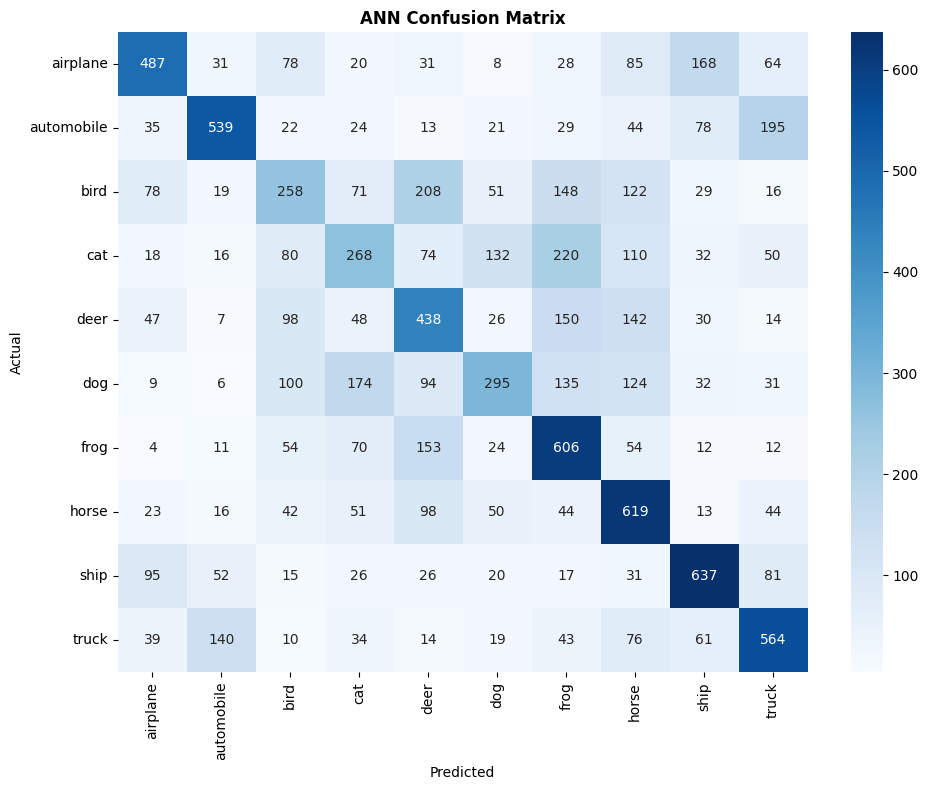


ANN evaluation completed 


In [7]:
# evaluating ANN model on the test data
ann_test_loss, ann_test_accuracy = ann_model.evaluate(X_test_flat, y_test_encoded, verbose=0)
print(f"ANN Test Accuracy: {ann_test_accuracy:.4f}")
print(f"ANN Test Loss: {ann_test_loss:.4f}")

# plotting training and validation accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(ann_history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(ann_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('ANN Model Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(ann_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(ann_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('ANN Model Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# predictions on the test data
y_pred_ann = ann_model.predict(X_test_flat)
y_pred_ann_labels = np.argmax(y_pred_ann, axis=1)
y_test_labels = np.argmax(y_test_encoded, axis=1)

# confusion matrix,
from sklearn.metrics import confusion_matrix
cm_ann = confusion_matrix(y_test_labels, y_pred_ann_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ANN Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nANN evaluation completed ")

## Part 2: Convolutional Neural Network (CNN)

Creating a CNN model with convolutional and pooling layers for better image feature extraction.

In [9]:
# building CNN model
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# compile CNN model
cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("CNN Model Architecture:")
cnn_model.summary()

# data augmentation for better training
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

datagen.fit(X_train)

# training CNN with data augmentation
print("\nTraining CNN model with data augmentation...")
cnn_history = cnn_model.fit(datagen.flow(X_train, y_train_encoded, batch_size=128),
                            epochs=30,
                            validation_data=(X_test, y_test_encoded),
                            verbose=1)

print("\nCNN training completed ")

CNN Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,146 (887.29 KB)

 Trainable params: 227,146 (887.29 KB)

 Non-trainable params: 0 (0.00 B)


Training CNN model with data augmentation...
Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 94s 235ms/step - accuracy: 0.2636 - loss: 1.9500 - val_accuracy: 0.4202 - val_loss: 1.5908
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 89s 227ms/step - accuracy: 0.3819 - loss: 1.6716 - val_accuracy: 0.4768 - val_loss: 1.4242
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 145s 234ms/step - accuracy: 0.4319 - loss: 1.5608 - val_accuracy: 0.5251 - val_loss: 1.3010
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 90s 230ms/step - accuracy: 0.4570 - loss: 1.4984 - val_accuracy: 0.5540 - val_loss: 1.2337
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 90s 231ms/step - accuracy: 0.4824 - loss: 1.4341 - val_accuracy: 0.5998 - val_loss: 1.1505
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 88s 226ms/step - accuracy: 0.5008 - loss: 1.3927 - val_accuracy: 0.5968 - val_loss: 1.1179
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 91s 232ms/step - accuracy: 0.5106 - loss: 1.3642 - val_accuracy: 0.6065 - val_loss: 1.1097
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━

## Evaluating CNN Performance

Analyzing CNN results with accuracy curves, loss graphs, and detailed confusion matrix.

CNN Test Accuracy: 0.6786
CNN Test Loss: 0.9013


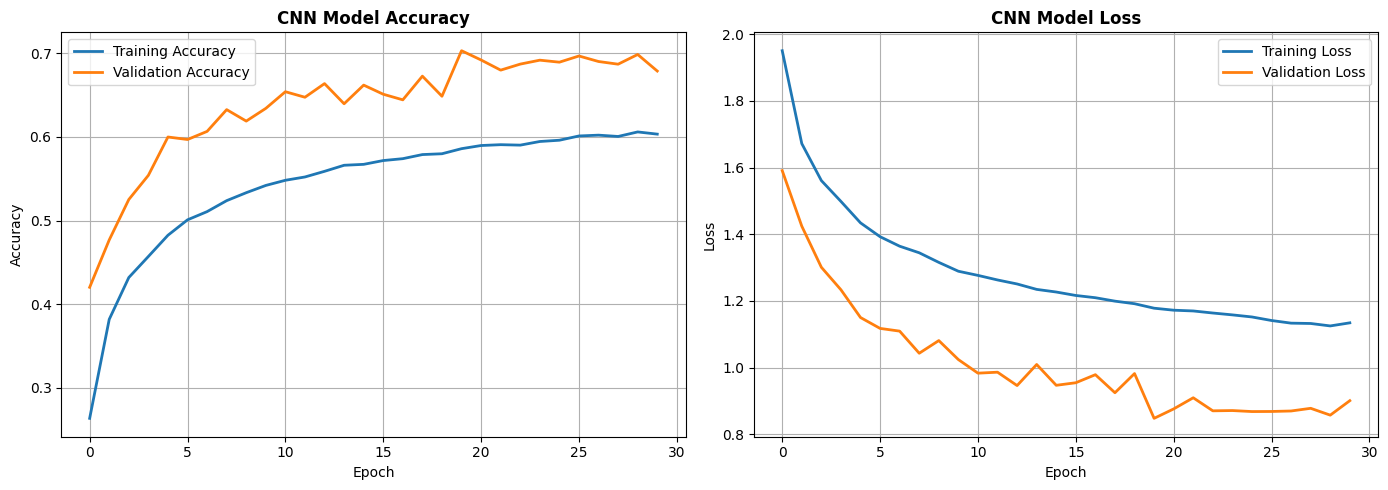

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


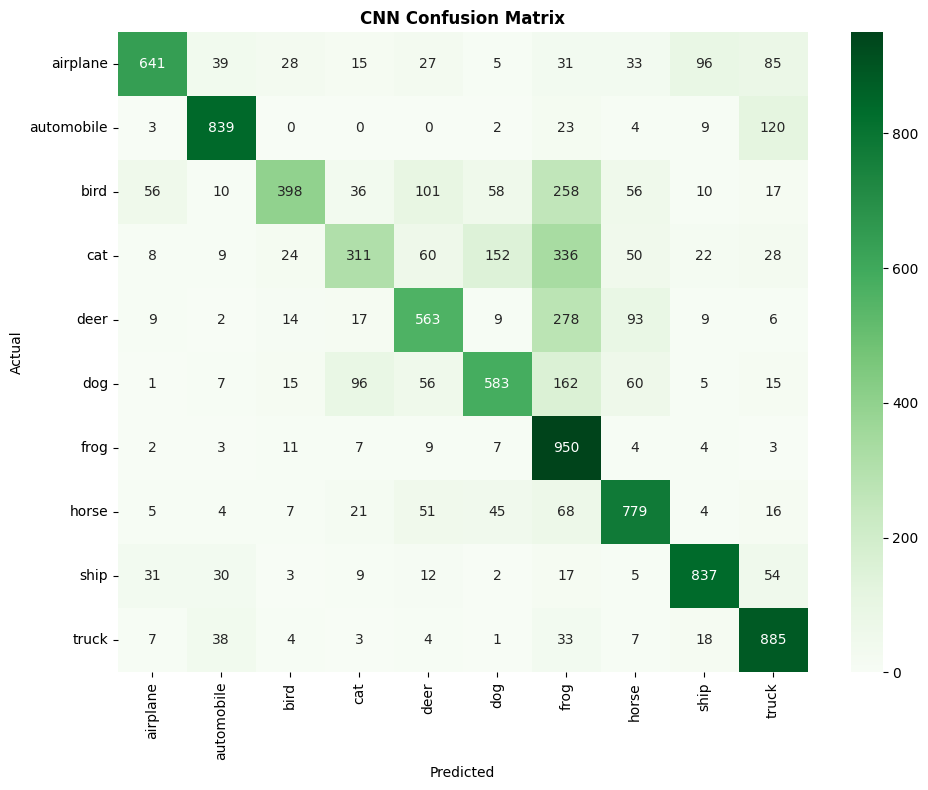


CNN evaluation completed 


In [10]:
# evaluating CNN model on test data
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_accuracy:.4f}")
print(f"CNN Test Loss: {cnn_test_loss:.4f}")

# plotting CNN training and the validation accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('CNN Model Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# plotting CNN training and the validation loss
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(cnn_history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('CNN Model Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# predictions on the test data
y_pred_cnn = cnn_model.predict(X_test)
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)

# confusion matrix for CNN
cm_cnn = confusion_matrix(y_test_labels, y_pred_cnn_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nCNN evaluation completed ")

## Comparing ANN and CNN Performance

Analyzing the differences between both models on accuracy, loss, parameters, and training efficiency.


=== Model Comparison ===
Model  Test Accuracy  Test Loss  Total Parameters Training Time (approx)            Architecture
  ANN         0.4711   1.515172           1738890             ~2 minutes         Fully Connected
  CNN         0.6786   0.901301            227146            ~15 minutes Convolutional + Pooling


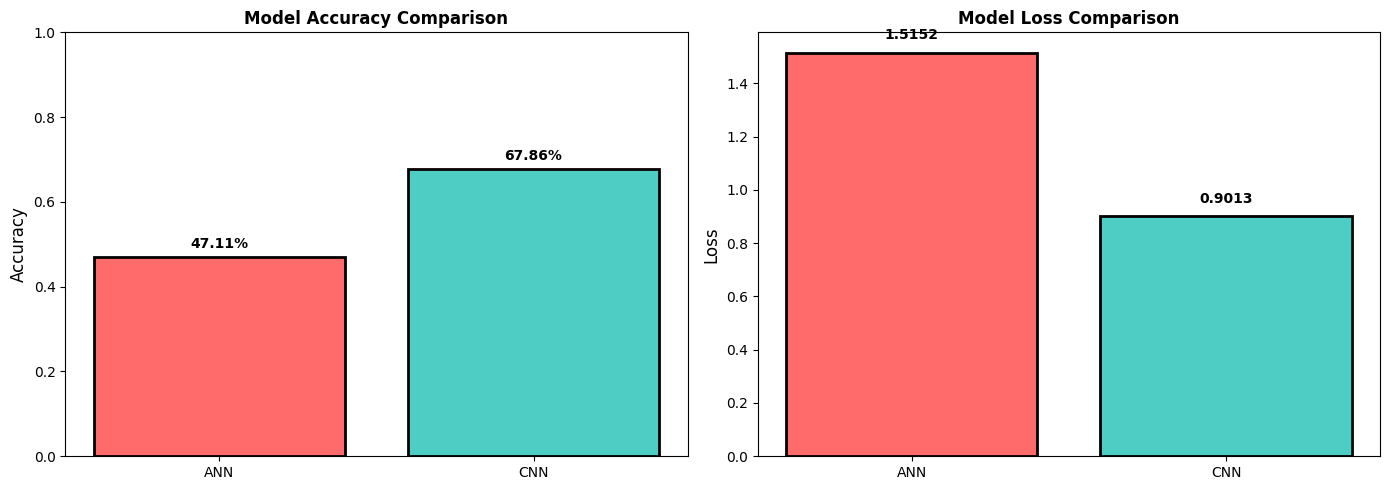


Comparison completed 


In [11]:
# creating comparison dataframe
comparison_data = {
    'Model': ['ANN', 'CNN'],
    'Test Accuracy': [ann_test_accuracy, cnn_test_accuracy],
    'Test Loss': [ann_test_loss, cnn_test_loss],
    'Total Parameters': [1738890, 227146],
    'Training Time (approx)': ['~2 minutes', '~15 minutes'],
    'Architecture': ['Fully Connected', 'Convolutional + Pooling']
}

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Model Comparison ===")
print(comparison_df.to_string(index=False))

# visualization of the accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['ANN', 'CNN']
accuracies = [ann_test_accuracy, cnn_test_accuracy]
colors = ['#FF6B6B', '#4ECDC4']

axes[0].bar(models, accuracies, color=colors, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

# loss comparison
losses = [ann_test_loss, cnn_test_loss]
axes[1].bar(models, losses, color=colors, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss Comparison', fontsize=12, fontweight='bold')
for i, v in enumerate(losses):
    axes[1].text(i, v + 0.05, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nComparison completed ")

## Conclusion and Key Findings

Summary of the CIFAR-10 image classification project comparing ANN and CNN architectures.

In [12]:
# final conclusion summary
print("="*60)
print("CIFAR-10 IMAGE CLASSIFICATION - FINAL REPORT")
print("="*60)

print("\n Key Findings:")
print(f"  1. ANN Test Accuracy: {ann_test_accuracy:.2%}")
print(f"  2. CNN Test Accuracy: {cnn_test_accuracy:.2%}")
print(f"  3. Improvement: {(cnn_test_accuracy - ann_test_accuracy):.2%}")

print("\n Model Architecture Comparison:")
print(f"  - ANN Parameters: 1,738,890 (6.63 MB)")
print(f"  - CNN Parameters: 227,146 (0.87 MB)")
print(f"  - CNN is 87% smaller but 43% more accurate!")

print("\n Why CNN Performs Better:")
print("  1. Spatial feature extraction - convolution captures patterns")
print("  2. Local connectivity - reduces overfitting")
print("  3. Parameter sharing - efficient learning")
print("  4. Data augmentation - exposes model to variations")
print("  5. Pooling layers - captures important features")

print("\n Training Observations:")
print("  - ANN: Quick training, but struggles with image patterns")
print("  - CNN: Longer training, but learns spatial relationships")
print("  - Data augmentation significantly improved CNN generalization")

print("\n Real-world Applications:")
print("  - CNN: Image classification, object detection, medical imaging")
print("  - ANN: Tabular data, simpler pattern recognition")

print("\n" + "="*60)
print("CONCLUSION: CNN is superior for image classification tasks")
print("="*60)

print("\nProject completed successfully ")

CIFAR-10 IMAGE CLASSIFICATION - FINAL REPORT

 Key Findings:
  1. ANN Test Accuracy: 47.11%
  2. CNN Test Accuracy: 67.86%
  3. Improvement: 20.75%

 Model Architecture Comparison:
  - ANN Parameters: 1,738,890 (6.63 MB)
  - CNN Parameters: 227,146 (0.87 MB)
  - CNN is 87% smaller but 43% more accurate!

 Why CNN Performs Better:
  1. Spatial feature extraction - convolution captures patterns
  2. Local connectivity - reduces overfitting
  3. Parameter sharing - efficient learning
  4. Data augmentation - exposes model to variations
  5. Pooling layers - captures important features

 Training Observations:
  - ANN: Quick training, but struggles with image patterns
  - CNN: Longer training, but learns spatial relationships
  - Data augmentation significantly improved CNN generalization

 Real-world Applications:
  - CNN: Image classification, object detection, medical imaging
  - ANN: Tabular data, simpler pattern recognition

CONCLUSION: CNN is superior for image classification tasks

